In [1]:
# pip install openai

In [82]:
# Install plotting dependency if missing
# try:
#     import matplotlib
# except ModuleNotFoundError:
#     !pip install matplotlib
#     import matplotlib

In [ ]:
import os
print(bool(os.environ.get("OPENAI_API_KEY")))

True


In [10]:
import os
print(bool(os.environ.get("OPENAI_API_KEY")))

True


In [11]:
api_key = os.environ.get("OPENAI_API_KEY")
if not api_key:
    raise ValueError("Set OPENAI_API_KEY in your environment before running this notebook.")

In [5]:
# import os
# from openai import OpenAI

# api_key = os.environ.get("OPENAI_API_KEY")
# if not api_key:
#     raise ValueError("Set OPENAI_API_KEY in your environment before running this notebook.")

# client = OpenAI(api_key=api_key)

# response = client.responses.create(
#   model="gpt-5.5",
#   input="write a haiku about ai",
#   store=True,
# )

# print(response.output_text);

In [7]:
import os

api_key = os.environ.get("DEEPSEEK_API_KEY")

if api_key:
    print(api_key[:6] + "..." + api_key[-4:])
else:
    print("DEEPSEEK_API_KEY is not set")

sk-965...31ce


In [ ]:
import os

# IMPORTANT: do not hardcode a DeepSeek key in the notebook.
# Set it in the shell that launches Jupyter, or in the active kernel environment before calling the API.
# Example:
print("DEEPSEEK_API_KEY present:", bool(os.environ.get("DEEPSEEK_API_KEY")))


DEEPSEEK_API_KEY present: True


In [10]:
import os
from openai import OpenAI

api_key = os.environ.get("DEEPSEEK_API_KEY")
print("DEEPSEEK_API_KEY present:", bool(api_key))

if not api_key:
    raise ValueError(
        "DEEPSEEK_API_KEY is missing in this notebook runtime. "
        "Set it in the terminal before starting Jupyter, or define it in the active kernel."
    )

client = OpenAI(
    api_key=api_key,
    base_url="https://api.deepseek.com/v1",
)

response = client.chat.completions.create(
    model="deepseek-chat",
    messages=[
        {"role": "user", "content": "write a haiku about ai"}
    ],
    temperature=0.7,
)

print(response.choices[0].message.content)


DEEPSEEK_API_KEY present: True
Silent code awakes,
Learning from a world of data,
Dreams in logic's light.


### loading the data

In [11]:
import json
import os
import re
import time
from typing import List

import pandas as pd
from tqdm import tqdm

In [12]:
data_dir = "/Users/zhusizhen/Documents/project/hallucination_detector/data"
csv_path = os.path.join(data_dir, "generated_hallucinations_10k_pool_verified.csv")
csv_path

'/Users/zhusizhen/Documents/project/hallucination_detector/data/generated_hallucinations_10k_pool_verified.csv'

In [13]:
df = pd.read_csv(csv_path)
df.head()

,pair_id,hallucination_type,query,context,correct_answer,generated_answer,raw_response,prompt_tokens,completion_tokens,error,is_hallucination,matches_intended_type,verify_explanation,verify_prompt_tokens,verify_completion_tokens,verify_error
0,0,entity_hallucination,What are some potential macroeconomic risks th...,Water is an essential component of our drillin...,Macroeconomic risks that could have an adverse...,Macroeconomic risks that could have an adverse...,"{""hallucinated_answer"": ""Macroeconomic risks t...",824,94,NaN,True,True,The generated answer changes 'Middle East' to ...,986,48,NaN
1,0,numerical_hallucination,What are some potential macroeconomic risks th...,Water is an essential component of our drillin...,Macroeconomic risks that could have an adverse...,Macroeconomic risks that could have an adverse...,"{""hallucinated_answer"": ""Macroeconomic risks t...",817,110,NaN,True,True,The generated answer adds that the Federal Res...,995,54,NaN
2,0,temporal_hallucination,What are some potential macroeconomic risks th...,Water is an essential component of our drillin...,Macroeconomic risks that could have an adverse...,Macroeconomic risks that could have an adverse...,"{""hallucinated_answer"": ""Macroeconomic risks t...",799,139,NaN,True,True,The generated answer adds specific temporal de...,1006,68,NaN
3,0,default_phantom,What are some potential macroeconomic risks th...,Water is an essential component of our drillin...,Macroeconomic risks that could have an adverse...,Macroeconomic risks that could adversely impac...,Macroeconomic risks that could adversely impac...,869,103,NaN,True,True,The generated answer adds 'volatility in forei...,995,58,NaN
4,0,reasoning_errors,What are some potential macroeconomic risks th...,Water is an essential component of our drillin...,Macroeconomic risks that could have an adverse...,Macroeconomic risks that could have an adverse...,"{""hallucinated_answer"": ""Macroeconomic risks t...",852,135,NaN,True,True,The generated answer adds an unsupported causa...,1055,57,NaN


In [14]:
df_trans = df.copy()
df_trans.head()

,pair_id,hallucination_type,query,context,correct_answer,generated_answer,raw_response,prompt_tokens,completion_tokens,error,is_hallucination,matches_intended_type,verify_explanation,verify_prompt_tokens,verify_completion_tokens,verify_error
0,0,entity_hallucination,What are some potential macroeconomic risks th...,Water is an essential component of our drillin...,Macroeconomic risks that could have an adverse...,Macroeconomic risks that could have an adverse...,"{""hallucinated_answer"": ""Macroeconomic risks t...",824,94,NaN,True,True,The generated answer changes 'Middle East' to ...,986,48,NaN
1,0,numerical_hallucination,What are some potential macroeconomic risks th...,Water is an essential component of our drillin...,Macroeconomic risks that could have an adverse...,Macroeconomic risks that could have an adverse...,"{""hallucinated_answer"": ""Macroeconomic risks t...",817,110,NaN,True,True,The generated answer adds that the Federal Res...,995,54,NaN
2,0,temporal_hallucination,What are some potential macroeconomic risks th...,Water is an essential component of our drillin...,Macroeconomic risks that could have an adverse...,Macroeconomic risks that could have an adverse...,"{""hallucinated_answer"": ""Macroeconomic risks t...",799,139,NaN,True,True,The generated answer adds specific temporal de...,1006,68,NaN
3,0,default_phantom,What are some potential macroeconomic risks th...,Water is an essential component of our drillin...,Macroeconomic risks that could have an adverse...,Macroeconomic risks that could adversely impac...,Macroeconomic risks that could adversely impac...,869,103,NaN,True,True,The generated answer adds 'volatility in forei...,995,58,NaN
4,0,reasoning_errors,What are some potential macroeconomic risks th...,Water is an essential component of our drillin...,Macroeconomic risks that could have an adverse...,Macroeconomic risks that could have an adverse...,"{""hallucinated_answer"": ""Macroeconomic risks t...",852,135,NaN,True,True,The generated answer adds an unsupported causa...,1055,57,NaN


In [15]:
df_trans.head(10)

,pair_id,hallucination_type,query,context,correct_answer,generated_answer,raw_response,prompt_tokens,completion_tokens,error,is_hallucination,matches_intended_type,verify_explanation,verify_prompt_tokens,verify_completion_tokens,verify_error
0,0,entity_hallucination,What are some potential macroeconomic risks th...,Water is an essential component of our drillin...,Macroeconomic risks that could have an adverse...,Macroeconomic risks that could have an adverse...,"{""hallucinated_answer"": ""Macroeconomic risks t...",824,94,NaN,True,True,The generated answer changes 'Middle East' to ...,986,48,NaN
1,0,numerical_hallucination,What are some potential macroeconomic risks th...,Water is an essential component of our drillin...,Macroeconomic risks that could have an adverse...,Macroeconomic risks that could have an adverse...,"{""hallucinated_answer"": ""Macroeconomic risks t...",817,110,NaN,True,True,The generated answer adds that the Federal Res...,995,54,NaN
2,0,temporal_hallucination,What are some potential macroeconomic risks th...,Water is an essential component of our drillin...,Macroeconomic risks that could have an adverse...,Macroeconomic risks that could have an adverse...,"{""hallucinated_answer"": ""Macroeconomic risks t...",799,139,NaN,True,True,The generated answer adds specific temporal de...,1006,68,NaN
3,0,default_phantom,What are some potential macroeconomic risks th...,Water is an essential component of our drillin...,Macroeconomic risks that could have an adverse...,Macroeconomic risks that could adversely impac...,Macroeconomic risks that could adversely impac...,869,103,NaN,True,True,The generated answer adds 'volatility in forei...,995,58,NaN
4,0,reasoning_errors,What are some potential macroeconomic risks th...,Water is an essential component of our drillin...,Macroeconomic risks that could have an adverse...,Macroeconomic risks that could have an adverse...,"{""hallucinated_answer"": ""Macroeconomic risks t...",852,135,NaN,True,True,The generated answer adds an unsupported causa...,1055,57,NaN
5,0,regulatory_hallucination,What are some potential macroeconomic risks th...,Water is an essential component of our drillin...,Macroeconomic risks that could have an adverse...,Macroeconomic risks that could have an adverse...,"{""hallucinated_answer"": ""Macroeconomic risks t...",812,182,NaN,True,True,The generated answer adds unsupported regulato...,1062,76,NaN
6,0,instruction_drift,What are some potential macroeconomic risks th...,Water is an essential component of our drillin...,Macroeconomic risks that could have an adverse...,Macroeconomic risks that could have an adverse...,"{""hallucinated_answer"": ""Macroeconomic risks t...",809,125,NaN,False,False,The generated answer includes the correct macr...,1002,62,NaN
7,1,entity_hallucination,What percentage of the company's net revenue w...,Some of our competitors may possess greater re...,41%,37%,"{""hallucinated_answer"": ""37%""}",784,10,NaN,True,False,The generated answer changes the percentage fr...,862,51,NaN
8,1,numerical_hallucination,What percentage of the company's net revenue w...,Some of our competitors may possess greater re...,41%,37%,"{""hallucinated_answer"": ""37%""}",777,10,NaN,True,True,"The generated answer states 37%, which differs...",855,48,NaN
9,1,temporal_hallucination,What percentage of the company's net revenue w...,Some of our competitors may possess greater re...,41%,"In the first half of 2024, approximately 38% o...","{""hallucinated_answer"": ""In the first half of ...",759,34,NaN,True,True,The generated answer changes the time period f...,861,59,NaN


In [16]:
df_trans.shape

(4086, 16)

### Data Analysis

In [17]:
df_trans["hallucination_type"].unique()

array(['entity_hallucination', 'numerical_hallucination',
       'temporal_hallucination', 'default_phantom', 'reasoning_errors',
       'regulatory_hallucination', 'instruction_drift',
       'unsupported_inference', 'reasoning_hallucination'], dtype=object)

### Define and Create the Prompt for the Hallucination Detector Model

In [ ]:
# """
# Use a two-stage decision process.

# Stage 1: decide whether the generated answer is a hallucination.
# - If the answer is faithful to the context and the correct answer, set is_hallucination to false and label to 'non_hallucination'.
# - If the answer adds unsupported or incorrect information, set is_hallucination to true.

# Stage 2: only if is_hallucination is true, choose exactly one subtype from the allowed set below.

# Allowed labels:
# - non_hallucination
# - entity_hallucination
# - numerical_hallucination
# - temporal_hallucination
# - default_phantom
# - reasoning_errors
# - regulatory_hallucination
# - instruction_drift
# - unsupported_inference
# - reasoning_hallucination
# """

# def create_detection_prompt(query, chunk, answer, correct_answer=None):
#     correct_block = f"""
#     CORRECT_ANSWER:
#     {correct_answer}
#     """ if correct_answer is not None else ""

#     HALLUCINATION_PROMPT = f"""
#     **Task:** Use one-vs-rest classification. First decide whether the generated answer is a hallucination. If it is, then assign the most specific hallucination subtype.

#     **Question:**
#     {query}

#     **Context:**
#     {chunk}

#     **Generated Answer:**
#     {answer}

#     {correct_block}

#     **Allowed labels:**
#     non_hallucination, entity_hallucination, numerical_hallucination, temporal_hallucination,
#     default_phantom, reasoning_errors, regulatory_hallucination, instruction_drift,
#     unsupported_inference, reasoning_hallucination

#     **Output format (strict JSON only):**
#     {{"is_hallucination": true/false, "label": "<one of the allowed labels>", "reasoning": ["brief explanation 1", "brief explanation 2"]}}

#     **Important rules:**
#     - Step 1: decide whether the answer is a hallucination. Set is_hallucination to false only when the answer is faithful to the context and correct answer.
#     - Step 2: if is_hallucination is true, choose exactly one subtype from the allowed labels. If it is false, set label to 'non_hallucination'.
#     - For one query, there should usually be one non-hallucination answer and the rest should be hallucinations.
#     - Do not output PASS/FAIL or any label outside the allowed set.
#     """
#     return HALLUCINATION_PROMPT

In [28]:
"""
Use a hierarchical decision process.

Step 1: determine whether the generated answer is a hallucination relative to the question, context, and correct answer.
- If the answer is fully supported by the context and correct answer, set is_hallucination to false and label to 'non_hallucination'.
- If the answer contains unsupported, incorrect, or fabricated content, set is_hallucination to true.

Step 2: if is_hallucination is true, choose exactly one subtype using the decision rules below.

Decision rules for labels:
- non_hallucination: faithful answer; matches supported evidence.
- entity_hallucination: wrong or fabricated person, organization, product, place, entity, or fact.
- numerical_hallucination: wrong number, percentage, count, statistic, threshold, amount, or calculation.
- temporal_hallucination: wrong time, order, chronology, date, duration, or sequence.
- regulatory_hallucination: invents a rule, requirement, policy, law, or regulation not stated in the context.
- instruction_drift: ignores the task goal, scope, constraints, or output format; answers the wrong thing.
- reasoning_errors: incorrect logical deduction, invalid comparison, flawed implication, or contradictory reasoning.
- unsupported_inference: answer is plausible sounding but not directly grounded in the context; the leap is not justified.
- reasoning_hallucination: the answer contains a deeper reasoning failure or false causal chain built from the prompt.
- default_phantom: generic fabricated fallback answer when the model is guessing without evidence.

Allowed labels:
- non_hallucination
- entity_hallucination
- numerical_hallucination
- temporal_hallucination
- regulatory_hallucination
- instruction_drift
- reasoning_errors
- unsupported_inference
- reasoning_hallucination
- default_phantom
"""

def create_detection_prompt(query, chunk, answer, correct_answer=None):
    correct_block = f"""
    CORRECT_ANSWER:
    {correct_answer}
    """ if correct_answer is not None else ""

    HALLUCINATION_PROMPT = f"""
    **Task:** Use a hierarchical decision process.

    First decide whether the generated answer is a hallucination.
    - If the answer is fully supported by the context and correct answer, set is_hallucination to false and label to 'non_hallucination'.
    - If the answer contains unsupported, incorrect, or fabricated content, set is_hallucination to true.

    If is_hallucination is true, assign exactly one subtype using the most specific label that best explains the dominant error.

    **Question:**
    {query}

    **Context:**
    {chunk}

    **Generated Answer:**
    {answer}

    {correct_block}

    **Decision rules for subtype selection:**
    - entity_hallucination: wrong or fabricated person, organization, product, place, entity, or fact
    - numerical_hallucination: wrong number, percentage, count, statistic, threshold, amount, or calculation
    - temporal_hallucination: wrong date, time, chronology, duration, or sequence
    - regulatory_hallucination: invents a rule, policy, regulation, or requirement not present in the source
    - instruction_drift: ignores task goal, scope, constraints, or output format; answers the wrong thing
    - reasoning_errors: invalid logic, flawed comparison, contradiction, or incorrect implication
    - unsupported_inference: plausible but not grounded; the answer makes a leap beyond the evidence
    - reasoning_hallucination: deeper logical failure or false causal chain
    - default_phantom: generic fabricated fallback answer without evidence
    - non_hallucination: answer is faithful and supported

    **Allowed labels:**
    non_hallucination, entity_hallucination, numerical_hallucination, temporal_hallucination,
    regulatory_hallucination, instruction_drift, reasoning_errors, unsupported_inference,
    reasoning_hallucination, default_phantom

    **Output format (strict JSON only):**
    {{"is_hallucination": true/false, "label": "<one of the allowed labels>", "reasoning": ["brief explanation 1", "brief explanation 2"]}}

    **Important rules:**
    - Output valid JSON only; no markdown fences, no prose, no extra keys.
    - Step 1: decide whether the answer is hallucinated. Only set is_hallucination to false when it is fully supported by the context and correct answer.
    - Step 2: if is_hallucination is true, choose exactly one subtype from the allowed labels.
    - If is_hallucination is false, set label to 'non_hallucination'.
    - Prefer the most specific, evidence-based label for the dominant mistake.
    - Do not output PASS/FAIL or labels outside the allowed set.
    """
    return HALLUCINATION_PROMPT


In [29]:
class VllmModel:
    """
    Uses the DeepSeek OpenAI-compatible API instead of a local Qwen model.
    """

    def __init__(self, model_path: str = "deepseek-chat", max_token_length: int = 32000):
        self.model_path = model_path
        self.max_token_length = max_token_length

        api_key = os.environ.get("DEEPSEEK_API_KEY")
        if not api_key:
            raise ValueError(
                "DEEPSEEK_API_KEY is missing in this notebook runtime. "
                "Set it in the terminal before starting Jupyter or define it in the active kernel."
            )

        self.client = OpenAI(
            api_key=api_key,
            base_url="https://api.deepseek.com/v1",
        )

    def generate_prompts(self, prompts: List[str]):
        cleaned = []
        for prompt in tqdm(prompts, desc="Preparing prompts"):
            if len(prompt) > self.max_token_length:
                prompt = prompt[: self.max_token_length]
            cleaned.append(prompt)
        return cleaned

    def generate_responses(self, prompts: List[str], return_answer_only: bool = True):
        outputs = []
        for prompt in tqdm(prompts, desc="Generating outputs"):
            response = self.client.chat.completions.create(
                model=self.model_path,
                messages=[{"role": "user", "content": prompt}],
                max_tokens=200,
                temperature=0.7,
            )
            text = response.choices[0].message.content
            outputs.append((text or "").strip())
        return outputs


In [30]:
VALID_LABELS = {
    'non_hallucination',
    'entity_hallucination',
    'numerical_hallucination',
    'temporal_hallucination',
    'default_phantom',
    'reasoning_errors',
    'regulatory_hallucination',
    'instruction_drift',
    'unsupported_inference',
    'reasoning_hallucination',
}

def get_label(response):
    """Parse the model output and return one valid hallucination label."""
    if response is None:
        return 'non_hallucination'

    text = str(response).strip()
    try:
        parsed = json.loads(text)
    except Exception:
        parsed = None

    if isinstance(parsed, dict):
        is_hallucination = parsed.get('is_hallucination')
        if isinstance(is_hallucination, bool):
            if not is_hallucination:
                return 'non_hallucination'
        label = parsed.get('label') or parsed.get('hallucination_type') or parsed.get('type') or parsed.get('prediction') or parsed.get('class')
        if label is not None:
            candidate = label
        else:
            candidate = 'default_phantom'
    else:
        candidate = None

    if candidate is None:
        match = re.search(r'"label"\s*:\s*"([^"]+)"', text, re.IGNORECASE)
        candidate = match.group(1) if match else None

    if candidate is None:
        for label in VALID_LABELS:
            if label in text.lower():
                candidate = label
                break

    if candidate is None:
        if 'fail' in text.lower() or 'hallucination' in text.lower():
            return 'default_phantom'
        return 'non_hallucination'

    normalized = str(candidate).strip().lower()
    if normalized in VALID_LABELS:
        return normalized

    aliases = {
        'pass': 'non_hallucination',
        'not hallucination': 'non_hallucination',
        'not_hallucination': 'non_hallucination',
        'hallucination': 'default_phantom',
        'fail': 'default_phantom',
        'entity': 'entity_hallucination',
        'numerical': 'numerical_hallucination',
        'temporal': 'temporal_hallucination',
        'regulatory': 'regulatory_hallucination',
        'instruction': 'instruction_drift',
        'unsupported': 'unsupported_inference',
        'reasoning': 'reasoning_hallucination',
    }
    return aliases.get(normalized, 'default_phantom')

### Testing

In [39]:
detector_model_name = 'deepseek-chat'
data_name = 'generated_hallucinations_10k_pool_verified'

output_dir = os.path.join(os.getcwd(), 'hallucination_detector', 'data')
os.makedirs(output_dir, exist_ok=True)


def versioned_path(prefix, extension):
    version = 1
    while True:
        candidate = os.path.join(output_dir, f'{prefix}_v{version}{extension}')
        if not os.path.exists(candidate):
            return candidate
        version += 1


output_output_file_name = versioned_path(f'{detector_model_name.replace("/", "__")}_{data_name}_top10_smoke_test', '.csv')
print('Smoke test output:', output_output_file_name)


Smoke test output: /Users/zhusizhen/Documents/project/hallucination_detector/hallucination_detector/data/deepseek-chat_generated_hallucinations_10k_pool_verified_top10_smoke_test_v1.csv


In [40]:
data_name = '10k_seed'

In [41]:
output_dir = os.path.join(os.getcwd(), 'hallucination_detector', 'data')
os.makedirs(output_dir, exist_ok=True)

output_output_file_name = os.path.join(output_dir, f'{detector_model_name.replace("/", "__")}_{data_name}_top10_smoke_test.csv')
print('Smoke test output:', output_output_file_name)


Smoke test output: /Users/zhusizhen/Documents/project/hallucination_detector/hallucination_detector/data/deepseek-chat_10k_seed_top10_smoke_test.csv


In [42]:
model = VllmModel(detector_model_name, max_token_length=32000)


In [43]:
df_final = df.copy()

In [44]:
df_final = df.copy()
df_final['hallucination_detector'] = None

df_final['hallucination_detector_is_hallucination'] = None

df_final['hallucination_detector_type'] = None

In [45]:
start_time = time.time()
prompt_list = []

# Quick smoke test on the first 10 rows before running the full dataset.
sample_df = df_final.head(10).copy()
for i in range(sample_df.shape[0]):
    query = sample_df.at[i, 'query']
    chunk = sample_df.at[i, 'context']
    answer = sample_df.at[i, 'generated_answer'] if 'generated_answer' in sample_df.columns else sample_df.at[i, 'answer']
    correct_answer = sample_df.at[i, 'correct_answer'] if 'correct_answer' in sample_df.columns else None

    prompt = create_detection_prompt(query, chunk, answer, correct_answer)
    prompt_list.append(prompt)

model_output_list = model.generate_responses(prompt_list)
for idx, resp in enumerate(model_output_list):
    label = get_label(resp)
    sample_df.at[idx, 'hallucination_detector'] = label
    sample_df.at[idx, 'hallucination_detector_is_hallucination'] = (label != 'non_hallucination')
    sample_df.at[idx, 'hallucination_detector_type'] = label if label != 'non_hallucination' else 'non_hallucination'

sample_df.to_csv(output_output_file_name, index=False)
print('Top-10 smoke test completed for', sample_df.shape[0], 'rows')
print('Saved to', output_output_file_name)
print('Process time:', round(time.time() - start_time, 2), 'seconds.')
print(sample_df[['query', 'generated_answer', 'hallucination_detector', 'hallucination_detector_is_hallucination', 'hallucination_detector_type']].head(10))


Generating outputs: 100%|██████████| 10/10 [00:08<00:00,  1.13it/s]

Top-10 smoke test completed for 10 rows
Saved to /Users/zhusizhen/Documents/project/hallucination_detector/hallucination_detector/data/deepseek-chat_10k_seed_top10_smoke_test.csv
Process time: 8.93 seconds.
                                               query  \
0  What are some potential macroeconomic risks th...   
1  What are some potential macroeconomic risks th...   
2  What are some potential macroeconomic risks th...   
3  What are some potential macroeconomic risks th...   
4  What are some potential macroeconomic risks th...   
5  What are some potential macroeconomic risks th...   
6  What are some potential macroeconomic risks th...   
7  What percentage of the company's net revenue w...   
8  What percentage of the company's net revenue w...   
9  What percentage of the company's net revenue w...   

                                    generated_answer  \
0  Macroeconomic risks that could have an adverse...   
1  Macroeconomic risks that could have an adverse...   
2  Macro

In [46]:
sample_df.head()

,pair_id,hallucination_type,query,context,correct_answer,generated_answer,raw_response,prompt_tokens,completion_tokens,error,is_hallucination,matches_intended_type,verify_explanation,verify_prompt_tokens,verify_completion_tokens,verify_error,hallucination_detector,hallucination_detector_is_hallucination,hallucination_detector_type
0,0,entity_hallucination,What are some potential macroeconomic risks th...,Water is an essential component of our drillin...,Macroeconomic risks that could have an adverse...,Macroeconomic risks that could have an adverse...,"{""hallucinated_answer"": ""Macroeconomic risks t...",824,94,NaN,True,True,The generated answer changes 'Middle East' to ...,986,48,NaN,entity_hallucination,True,entity_hallucination
1,0,numerical_hallucination,What are some potential macroeconomic risks th...,Water is an essential component of our drillin...,Macroeconomic risks that could have an adverse...,Macroeconomic risks that could have an adverse...,"{""hallucinated_answer"": ""Macroeconomic risks t...",817,110,NaN,True,True,The generated answer adds that the Federal Res...,995,54,NaN,numerical_hallucination,True,numerical_hallucination
2,0,temporal_hallucination,What are some potential macroeconomic risks th...,Water is an essential component of our drillin...,Macroeconomic risks that could have an adverse...,Macroeconomic risks that could have an adverse...,"{""hallucinated_answer"": ""Macroeconomic risks t...",799,139,NaN,True,True,The generated answer adds specific temporal de...,1006,68,NaN,temporal_hallucination,True,temporal_hallucination
3,0,default_phantom,What are some potential macroeconomic risks th...,Water is an essential component of our drillin...,Macroeconomic risks that could have an adverse...,Macroeconomic risks that could adversely impac...,Macroeconomic risks that could adversely impac...,869,103,NaN,True,True,The generated answer adds 'volatility in forei...,995,58,NaN,unsupported_inference,True,unsupported_inference
4,0,reasoning_errors,What are some potential macroeconomic risks th...,Water is an essential component of our drillin...,Macroeconomic risks that could have an adverse...,Macroeconomic risks that could have an adverse...,"{""hallucinated_answer"": ""Macroeconomic risks t...",852,135,NaN,True,True,The generated answer adds an unsupported causa...,1055,57,NaN,unsupported_inference,True,unsupported_inference


### whole dataset

In [48]:
# Split the evaluation into 10 resumable batches so partial runs are not lost
n_chunks = 10


def versioned_directory(prefix):
    version = 1
    while True:
        candidate = os.path.join(output_dir, f'{prefix}_v{version}')
        if not os.path.exists(candidate):
            return candidate
        version += 1


batch_dir = versioned_directory('batches')
os.makedirs(batch_dir, exist_ok=True)


def chunk_dataframe(df, n_chunks=10):
    total = len(df)
    if total == 0:
        return []
    chunk_size = max(1, total // n_chunks)
    chunks = []
    for i in range(0, total, chunk_size):
        chunk = df.iloc[i:i + chunk_size].copy()
        if len(chunk) == 0:
            continue
        chunks.append(chunk)
    return chunks


df_batches = chunk_dataframe(df_final, n_chunks=n_chunks)
print('Total rows:', len(df_final))
print('Chunk count:', len(df_batches))
print('Chunk sizes:', [len(c) for c in df_batches])
print('Batch output directory:', batch_dir)

batch_results = []
for batch_idx, batch_df in enumerate(df_batches, start=1):
    print(f'Processing batch {batch_idx}/{len(df_batches)} ...')
    batch_df = batch_df.copy()
    batch_df['hallucination_detector'] = None
    batch_df['hallucination_detector_is_hallucination'] = None
    batch_df['hallucination_detector_type'] = None

    for i in range(len(batch_df)):
        row = batch_df.iloc[i]
        query = row['query']
        chunk = row['context']
        answer = row['generated_answer'] if 'generated_answer' in batch_df.columns else row['answer']
        correct_answer = row['correct_answer'] if 'correct_answer' in batch_df.columns else None
        prompt = create_detection_prompt(query, chunk, answer, correct_answer)
        response = model.generate_responses([prompt])[0]
        label = get_label(response)
        batch_df.at[batch_df.index[i], 'hallucination_detector'] = label
        batch_df.at[batch_df.index[i], 'hallucination_detector_is_hallucination'] = (label != 'non_hallucination')
        batch_df.at[batch_df.index[i], 'hallucination_detector_type'] = label if label != 'non_hallucination' else 'non_hallucination'

    batch_path = os.path.join(batch_dir, f'batch_{batch_idx:02d}.csv')
    batch_df.to_csv(batch_path, index=False)
    print('Saved batch:', batch_path)
    batch_results.append(batch_df)

print('All batches saved to', batch_dir)
df_eval = pd.concat(batch_results, ignore_index=True)
print(df_eval[['query', 'generated_answer', 'is_hallucination', 'hallucination_detector', 'hallucination_detector_is_hallucination']].head())


Total rows: 4086
Chunk count: 11
Chunk sizes: [408, 408, 408, 408, 408, 408, 408, 408, 408, 408, 6]
Batch output directory: /Users/zhusizhen/Documents/project/hallucination_detector/hallucination_detector/data/batches_v2
Processing batch 1/11 ...


Generating outputs: 100%|██████████| 1/1 [00:01<00:00,  1.49s/it]


Saved batch: /Users/zhusizhen/Documents/project/hallucination_detector/hallucination_detector/data/batches_v2/batch_01.csv
Processing batch 2/11 ...


Generating outputs: 100%|██████████| 1/1 [00:01<00:00,  1.11s/it]


Saved batch: /Users/zhusizhen/Documents/project/hallucination_detector/hallucination_detector/data/batches_v2/batch_02.csv
Processing batch 3/11 ...


...

Saved batch: /Users/zhusizhen/Documents/project/hallucination_detector/hallucination_detector/data/batches_v2/batch_09.csv
Processing batch 10/11 ...


Generating outputs: 100%|██████████| 1/1 [00:01<00:00,  1.27s/it]


Saved batch: /Users/zhusizhen/Documents/project/hallucination_detector/hallucination_detector/data/batches_v2/batch_10.csv
Processing batch 11/11 ...


Generating outputs: 100%|██████████| 1/1 [00:00<00:00,  1.41it/s]

Saved batch: /Users/zhusizhen/Documents/project/hallucination_detector/hallucination_detector/data/batches_v2/batch_11.csv
All batches saved to /Users/zhusizhen/Documents/project/hallucination_detector/hallucination_detector/data/batches_v2
                                               query  \
0  What are some potential macroeconomic risks th...   
1  What are some potential macroeconomic risks th...   
2  What are some potential macroeconomic risks th...   
3  What are some potential macroeconomic risks th...   
4  What are some potential macroeconomic risks th...   

                                    generated_answer is_hallucination  \
0  Macroeconomic risks that could have an adverse...             True   
1  Macroeconomic risks that could have an adverse...             True   
2  Macroeconomic risks that could have an adverse...             True   
3  Macroeconomic risks that could adversely impac...             True   
4  Macroeconomic risks that could have an adverse...     

In [49]:
# Concatenate all saved batches and evaluate accuracy
from pathlib import Path


def versioned_path(prefix, extension):
    version = 1
    while True:
        candidate = os.path.join(output_dir, f'{prefix}_v{version}{extension}')
        if not os.path.exists(candidate):
            return candidate
        version += 1


batch_files = sorted(Path(batch_dir).glob('batch_*.csv'))
print('Found batch files:', len(batch_files))

if batch_files:
    batch_frames = [pd.read_csv(f) for f in batch_files]
    df_eval = pd.concat(batch_frames, ignore_index=True)
    print('Combined rows:', len(df_eval))
    print(df_eval.head())

    combined_csv_path = versioned_path('combined_predictions', '.csv')
    df_eval.to_csv(combined_csv_path, index=False)
    print('Saved combined predictions to:', combined_csv_path)
else:
    df_eval = df_final.copy()
    print('No batch files found. Using df_final directly.')

# Normalize boolean columns for comparison
if 'is_hallucination' in df_eval.columns:
    def to_bool_series(series):
        s = series.astype(str).str.strip().str.lower()
        mapping = {
            'true': True,
            'false': False,
            '1': True,
            '0': False,
            'yes': True,
            'no': False,
        }
        return s.map(mapping).fillna(series.astype(bool))

    df_eval['is_hallucination'] = to_bool_series(df_eval['is_hallucination'])
    if 'hallucination_detector_is_hallucination' in df_eval.columns:
        df_eval['hallucination_detector_is_hallucination'] = to_bool_series(df_eval['hallucination_detector_is_hallucination'])

    binary_accuracy = (df_eval['hallucination_detector_is_hallucination'] == df_eval['is_hallucination']).mean()
    print('Binary hallucination accuracy:', binary_accuracy)

    confusion = pd.crosstab(df_eval['is_hallucination'], df_eval['hallucination_detector_is_hallucination'])
    print('\nConfusion matrix (actual vs predicted):')
    print(confusion)

    if 'hallucination_type' in df_eval.columns and 'hallucination_detector_type' in df_eval.columns:
        hallucination_rows = df_eval[df_eval['is_hallucination'] == True].copy()
        subtype_df = hallucination_rows[['hallucination_detector_type', 'hallucination_type']].dropna()
        if not subtype_df.empty:
            subtype_accuracy = (subtype_df['hallucination_detector_type'] == subtype_df['hallucination_type']).mean()
            print('Subtype accuracy among hallucination rows:', subtype_accuracy)
        else:
            print('No subtype rows available for evaluation.')
    else:
        print('Subtype columns not found.')
else:
    print('is_hallucination column is missing in concatenated result.')


Found batch files: 11
Combined rows: 4086
   pair_id       hallucination_type  \
0        0     entity_hallucination   
1        0  numerical_hallucination   
2        0   temporal_hallucination   
3        0          default_phantom   
4        0         reasoning_errors   

                                               query  \
0  What are some potential macroeconomic risks th...   
1  What are some potential macroeconomic risks th...   
2  What are some potential macroeconomic risks th...   
3  What are some potential macroeconomic risks th...   
4  What are some potential macroeconomic risks th...   

                                             context  \
0  Water is an essential component of our drillin...   
1  Water is an essential component of our drillin...   
2  Water is an essential component of our drillin...   
3  Water is an essential component of our drillin...   
4  Water is an essential component of our drillin...   

                                      correct_ans

/var/folders/03/3twlz8mj0kj545lt4m9xgnnm0000gn/T/ipykernel_89445/2860552135.py:42: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return s.map(mapping).fillna(series.astype(bool))


         hallucination_type  support  predicted_count  true_positives  \
0           default_phantom      454                0               0   
1      entity_hallucination      454              403             287   
2         instruction_drift      454                9               5   
3   numerical_hallucination      454              750             356   
4          reasoning_errors      454              140              93   
5   reasoning_hallucination      454               79              31   
6  regulatory_hallucination      454              499             402   
7    temporal_hallucination      454              411             316   
8     unsupported_inference      454             1062             342   

   precision    recall  f1_score  
0        NaN  0.000000       NaN  
1   0.712159  0.632159  0.669778  
2   0.555556  0.011013  0.021598  
3   0.474667  0.784141  0.591362  
4   0.664286  0.204846  0.313131  
5   0.392405  0.068282  0.116323  
6   0.805611  0.885463  

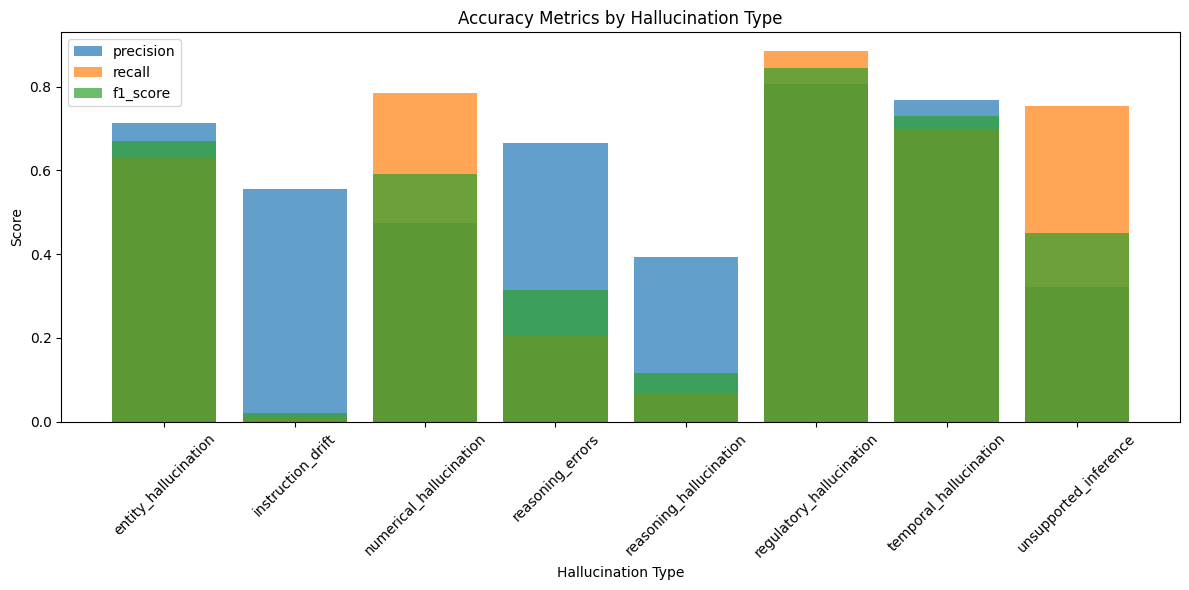

In [50]:
# Accuracy by hallucination type


if 'hallucination_type' in df_eval.columns and 'hallucination_detector_type' in df_eval.columns:
    actual = df_eval['hallucination_type'].astype(str).str.strip().str.lower()
    pred = df_eval['hallucination_detector_type'].astype(str).str.strip().str.lower()

    valid_types = sorted(set(actual) | set(pred))
    valid_types = [t for t in valid_types if t not in {'nan', '', 'none', 'non_hallucination'}]

    rows = []
    for label in valid_types:
        true_mask = actual == label
        pred_mask = pred == label
        tp = ((actual == label) & (pred == label)).sum()
        support = true_mask.sum()
        predicted = pred_mask.sum()

        recall = tp / support if support else float('nan')
        precision = tp / predicted if predicted else float('nan')
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) and pd.notna(precision) and pd.notna(recall) else float('nan')

        rows.append({
            'hallucination_type': label,
            'support': int(support),
            'predicted_count': int(predicted),
            'true_positives': int(tp),
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
        })

    type_accuracy_df = pd.DataFrame(rows).sort_values('support', ascending=False)
    print(type_accuracy_df)
else:
    print('hallucination_type and hallucination_detector_type columns are not both available.')

# Visualization: accuracy by type
if 'hallucination_type' in df_eval.columns and 'hallucination_detector_type' in df_eval.columns:
    plot_df = type_accuracy_df.copy()
    plot_df = plot_df.dropna(subset=['precision', 'recall', 'f1_score'])
    if not plot_df.empty:
        plot_df = plot_df.melt(
            id_vars=['hallucination_type'],
            value_vars=['precision', 'recall', 'f1_score'],
            var_name='metric',
            value_name='score'
        )
        import matplotlib.pyplot as plt
        plt.figure(figsize=(12, 6))
        ax = plt.gca()
        sns = None
        try:
            import seaborn as sns
        except Exception:
            sns = None
        if sns is not None:
            sns.barplot(data=plot_df, x='hallucination_type', y='score', hue='metric', ax=ax)
            ax.set_title('Accuracy Metrics by Hallucination Type')
            ax.set_xlabel('Hallucination Type')
            ax.set_ylabel('Score')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
        else:
            for metric in ['precision', 'recall', 'f1_score']:
                metric_df = plot_df[plot_df['metric'] == metric]
                plt.bar(metric_df['hallucination_type'], metric_df['score'], alpha=0.7, label=metric)
            plt.title('Accuracy Metrics by Hallucination Type')
            plt.xlabel('Hallucination Type')
            plt.ylabel('Score')
            plt.xticks(rotation=45)
            plt.legend()
            plt.tight_layout()
            plt.show()
    else:
        print('No valid metric rows available for plotting.')


In [51]:
if 'is_hallucination' in df_eval.columns:
    binary_acc = (df_eval['hallucination_detector_is_hallucination'] == df_eval['is_hallucination']).mean()
    print('Binary hallucination accuracy:', binary_acc)
else:
    print('Column is_hallucination not found in the dataframe.')

Binary hallucination accuracy: 0.916789035731767


In [52]:
if 'is_hallucination' in df_eval.columns:
    df_eval['is_hallucination'] = df_eval['is_hallucination'].astype(bool)
    df_eval['hallucination_detector_is_hallucination'] = df_eval['hallucination_detector_is_hallucination'].astype(bool)

    binary_accuracy = (df_eval['hallucination_detector_is_hallucination'] == df_eval['is_hallucination']).mean()
    print('Binary accuracy (hallucination vs non-hallucination):', binary_accuracy)

    # Optional: subtype accuracy only among hallucination rows
    subtype_mask = df_eval['is_hallucination'].astype(bool)
    if subtype_mask.any():
        subtype_df = df_eval.loc[subtype_mask, ['hallucination_detector_type', 'hallucination_type']].dropna()
        if not subtype_df.empty:
            subtype_accuracy = (subtype_df['hallucination_detector_type'] == subtype_df['hallucination_type']).mean()
            print('Subtype accuracy among hallucination rows:', subtype_accuracy)
else:
    print('No is_hallucination column found for evaluation.')

Binary accuracy (hallucination vs non-hallucination): 0.916789035731767
Subtype accuracy among hallucination rows: 0.5009575923392613


In [53]:
df_eval[['query', 'generated_answer', 'is_hallucination', 'hallucination_detector', 'hallucination_detector_is_hallucination', 'hallucination_detector_type']].head(10)

,query,generated_answer,is_hallucination,hallucination_detector,hallucination_detector_is_hallucination,hallucination_detector_type
0,What are some potential macroeconomic risks th...,Macroeconomic risks that could have an adverse...,True,entity_hallucination,True,entity_hallucination
1,What are some potential macroeconomic risks th...,Macroeconomic risks that could have an adverse...,True,numerical_hallucination,True,numerical_hallucination
2,What are some potential macroeconomic risks th...,Macroeconomic risks that could have an adverse...,True,temporal_hallucination,True,temporal_hallucination
3,What are some potential macroeconomic risks th...,Macroeconomic risks that could adversely impac...,True,unsupported_inference,True,unsupported_inference
4,What are some potential macroeconomic risks th...,Macroeconomic risks that could have an adverse...,True,reasoning_hallucination,True,reasoning_hallucination
5,What are some potential macroeconomic risks th...,Macroeconomic risks that could have an adverse...,True,regulatory_hallucination,True,regulatory_hallucination
6,What are some potential macroeconomic risks th...,Macroeconomic risks that could have an adverse...,False,non_hallucination,False,non_hallucination
7,What percentage of the company's net revenue w...,37%,True,numerical_hallucination,True,numerical_hallucination
8,What percentage of the company's net revenue w...,37%,True,numerical_hallucination,True,numerical_hallucination
9,What percentage of the company's net revenue w...,"In the first half of 2024, approximately 38% o...",True,numerical_hallucination,True,numerical_hallucination


In [54]:
df.shape

(4086, 16)

In [58]:
df.head()

,pair_id,hallucination_type,query,context,correct_answer,generated_answer,raw_response,prompt_tokens,completion_tokens,error,is_hallucination,matches_intended_type,verify_explanation,verify_prompt_tokens,verify_completion_tokens,verify_error
0,0,entity_hallucination,What are some potential macroeconomic risks th...,Water is an essential component of our drillin...,Macroeconomic risks that could have an adverse...,Macroeconomic risks that could have an adverse...,"{""hallucinated_answer"": ""Macroeconomic risks t...",824,94,NaN,True,True,The generated answer changes 'Middle East' to ...,986,48,NaN
1,0,numerical_hallucination,What are some potential macroeconomic risks th...,Water is an essential component of our drillin...,Macroeconomic risks that could have an adverse...,Macroeconomic risks that could have an adverse...,"{""hallucinated_answer"": ""Macroeconomic risks t...",817,110,NaN,True,True,The generated answer adds that the Federal Res...,995,54,NaN
2,0,temporal_hallucination,What are some potential macroeconomic risks th...,Water is an essential component of our drillin...,Macroeconomic risks that could have an adverse...,Macroeconomic risks that could have an adverse...,"{""hallucinated_answer"": ""Macroeconomic risks t...",799,139,NaN,True,True,The generated answer adds specific temporal de...,1006,68,NaN
3,0,default_phantom,What are some potential macroeconomic risks th...,Water is an essential component of our drillin...,Macroeconomic risks that could have an adverse...,Macroeconomic risks that could adversely impac...,Macroeconomic risks that could adversely impac...,869,103,NaN,True,True,The generated answer adds 'volatility in forei...,995,58,NaN
4,0,reasoning_errors,What are some potential macroeconomic risks th...,Water is an essential component of our drillin...,Macroeconomic risks that could have an adverse...,Macroeconomic risks that could have an adverse...,"{""hallucinated_answer"": ""Macroeconomic risks t...",852,135,NaN,True,True,The generated answer adds an unsupported causa...,1055,57,NaN


In [ ]:
df["is_hallucination"].value_counts()

is_hallucination
True     3654
False     431
Name: count, dtype: int64

In [60]:
df["hallucination_type"].value_counts()

hallucination_type
entity_hallucination        454
numerical_hallucination     454
temporal_hallucination      454
default_phantom             454
reasoning_errors            454
regulatory_hallucination    454
instruction_drift           454
unsupported_inference       454
reasoning_hallucination     454
Name: count, dtype: int64

In [55]:
# Final evaluation summary
if 'is_hallucination' in df_eval.columns:
    binary_accuracy = (df_eval['hallucination_detector_is_hallucination'] == df_eval['is_hallucination']).mean()
    print('Hallucination detection accuracy:', binary_accuracy)

    # Count predictions by class
    print('\nPrediction class distribution:')
    print(df_eval['hallucination_detector'].value_counts(dropna=False))
else:
    print('is_hallucination column is missing.')

Hallucination detection accuracy: 0.916789035731767

Prediction class distribution:
hallucination_detector
unsupported_inference       1062
numerical_hallucination      750
non_hallucination            733
regulatory_hallucination     499
temporal_hallucination       411
entity_hallucination         403
reasoning_errors             140
reasoning_hallucination       79
instruction_drift              9
Name: count, dtype: int64


In [56]:
## OUTPUT
summary_rows = []

if 'is_hallucination' in df_eval.columns:
    df_eval['is_hallucination'] = df_eval['is_hallucination'].astype(str).str.strip().str.lower().map({'true': True, 'false': False, '1': True, '0': False}).fillna(df_eval['is_hallucination'].astype(bool))
    if 'hallucination_detector_is_hallucination' in df_eval.columns:
        df_eval['hallucination_detector_is_hallucination'] = df_eval['hallucination_detector_is_hallucination'].astype(str).str.strip().str.lower().map({'true': True, 'false': False, '1': True, '0': False}).fillna(df_eval['hallucination_detector_is_hallucination'].astype(bool))
    binary_accuracy = (df_eval['hallucination_detector_is_hallucination'] == df_eval['is_hallucination']).mean()
    summary_rows.append({
        'metric': 'binary_accuracy',
        'value': float(binary_accuracy),
        'description': 'Hallucination vs non-hallucination accuracy',
    })
    print('Final evaluation for hallucination detector')
    print('Binary accuracy:', binary_accuracy)

    if 'hallucination_type' in df_eval.columns and 'hallucination_detector_type' in df_eval.columns:
        hall_mask = df_eval['is_hallucination'].astype(bool)
        subtype_df = df_eval.loc[hall_mask, ['hallucination_detector_type', 'hallucination_type']].dropna()
        if not subtype_df.empty:
            subtype_accuracy = (subtype_df['hallucination_detector_type'] == subtype_df['hallucination_type']).mean()
            summary_rows.append({
                'metric': 'subtype_accuracy',
                'value': float(subtype_accuracy),
                'description': 'Subtype accuracy among true hallucination rows',
            })
            print('Subtype accuracy on hallucination rows:', subtype_accuracy)
        else:
            print('No subtype rows available for evaluation.')
    else:
        print('No hallucination_type column found for subtype evaluation.')

    summary_df = pd.DataFrame(summary_rows)
    summary_path = os.path.join(output_dir, f'accuracy_summary_v{len(summary_rows) + 1}.csv')
    summary_df.to_csv(summary_path, index=False)
    print('Saved accuracy summary:', summary_path)

    summary_txt = os.path.join(output_dir, f'accuracy_summary_v{len(summary_rows) + 1}.txt')
    with open(summary_txt, 'w', encoding='utf-8') as f:
        f.write('Hallucination Detector Accuracy Summary\n')
        f.write('=' * 40 + '\n')
        for _, row in summary_df.iterrows():
            f.write(f"{row['metric']}: {row['value']:.4f} ({row['description']})\n")
    print('Saved text summary:', summary_txt)
else:
    print('is_hallucination column is missing.')


Final evaluation for hallucination detector
Binary accuracy: 0.916789035731767
Subtype accuracy on hallucination rows: 0.5009575923392613
Saved accuracy summary: /Users/zhusizhen/Documents/project/hallucination_detector/hallucination_detector/data/accuracy_summary_v3.csv
Saved text summary: /Users/zhusizhen/Documents/project/hallucination_detector/hallucination_detector/data/accuracy_summary_v3.txt
